In [1]:
import pandas as pd
import numpy as np
from main_source import split_data, rename_columns
from neuralprophet import NeuralProphet
import matplotlib.pyplot as plt

D:\jubelio_test\.jubelio_test\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [2]:
# Total orders 10 Company 
daily_orders = pd.read_csv('daily_orders_2024_2025.csv')
daily_orders.head()
df = rename_columns(daily_orders)
df.head()

,ds,y,ID
0,2024-01-01,7854,Company_B
1,2024-01-02,3802,Company_B
2,2024-01-03,3676,Company_B
3,2024-01-04,3457,Company_B
4,2024-01-05,3554,Company_B


In [3]:
# initialization model
m = NeuralProphet(
    trend_global_local="global",
    season_global_local="global",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
)
# global split in dataset 
df_train, df_val = m.split_df(df, valid_p=0.2, local_split=False)

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is 

In [4]:
metrics = m.fit(df_train, validation_df=df_val, progress=None)
metrics

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is 

,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss
0,0.778329,0.952010,0.640029,0.0,0,0.573893,0.0,0.908876,1.082483,0.572283,0.0
1,0.331703,0.458500,0.213035,0.0,1,0.227795,0.0,0.433952,0.541259,0.227060,0.0
2,0.284157,0.429044,0.171219,0.0,2,0.097152,0.0,0.241540,0.325678,0.096946,0.0
3,0.289243,0.433449,0.175060,0.0,3,0.093190,0.0,0.236973,0.319776,0.093482,0.0
4,0.277058,0.411974,0.164869,0.0,4,0.092793,0.0,0.235635,0.316012,0.092630,0.0
...,...,...,...,...,...,...,...,...,...,...,...
65,0.297594,0.447250,0.183366,0.0,65,0.090161,0.0,0.231337,0.311309,0.089937,0.0
66,0.299150,0.449290,0.184673,0.0,66,0.090142,0.0,0.232022,0.313198,0.090302,0.0
67,0.298717,0.449168,0.184462,0.0,67,0.090176,0.0,0.231507,0.312649,0.090070,0.0
68,0.301729,0.452982,0.187080,0.0,68,0.090213,0.0,0.231586,0.310946,0.090156,0.0


In [5]:
forecast = m.predict(df)
forecast

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warni

,ds,y,ID,yhat1,trend,season_yearly,season_weekly,season_daily
0,2024-01-01,9560,Company_A,6575.932617,1199.894165,95.248817,252.640015,5028.149414
1,2024-01-02,6535,Company_A,6187.671387,1201.462524,60.801094,-82.090591,5007.498535
2,2024-01-03,6269,Company_A,6256.846680,1203.030762,24.712179,-9.160666,5038.264160
3,2024-01-04,6069,Company_A,6272.164062,1204.598999,-12.691695,54.339081,5025.917969
4,2024-01-05,5898,Company_A,6198.110840,1206.167358,-51.572636,31.499048,5012.017090
...,...,...,...,...,...,...,...,...
7305,2025-12-27,1418,Company_J,1870.924805,-100.750793,91.345779,-108.842384,1989.171997
7306,2025-12-28,1707,Company_J,1974.723511,-101.857422,80.456215,11.360890,1984.764038
7307,2025-12-29,2023,Company_J,2046.278198,-102.964172,68.965240,99.651688,1980.625366
7308,2025-12-30,2049,Company_J,1908.755249,-104.070862,56.878239,-32.583244,1988.531006


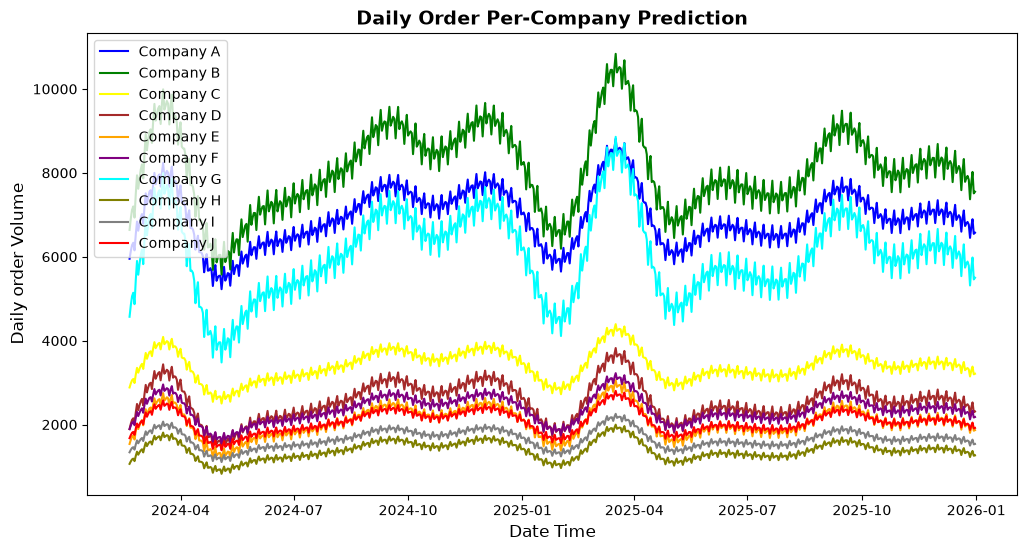

In [6]:
#plotting result 
fig, ax1 = plt.subplots(figsize=(12, 6))
# company A
company_a = forecast[forecast['ID']=='Company_A']
company_a_x = np.array(pd.to_datetime(company_a['ds']))
company_a_y = np.array(company_a['yhat1'])
# company B
company_b = forecast[forecast['ID']=='Company_B']
company_b_x = np.array(pd.to_datetime(company_b['ds']))
company_b_y = np.array(company_b['yhat1'])
# company C
company_c = forecast[forecast['ID']=='Company_C']
company_c_x = np.array(pd.to_datetime(company_c['ds']))
company_c_y = np.array(company_c['yhat1'])
# company D
company_d = forecast[forecast['ID']=='Company_D']
company_d_x = np.array(pd.to_datetime(company_d['ds']))
company_d_y = np.array(company_d['yhat1'])
# company E
company_e = forecast[forecast['ID']=='Company_E']
company_e_x = np.array(pd.to_datetime(company_e['ds']))
company_e_y = np.array(company_e['yhat1'])
# company F
company_f = forecast[forecast['ID']=='Company_F']
company_f_x = np.array(pd.to_datetime(company_f['ds']))
company_f_y = np.array(company_f['yhat1'])
# company G
company_g = forecast[forecast['ID']=='Company_G']
company_g_x = np.array(pd.to_datetime(company_g['ds']))
company_g_y = np.array(company_g['yhat1'])
# company H
company_h = forecast[forecast['ID']=='Company_H']
company_h_x = np.array(pd.to_datetime(company_h['ds']))
company_h_y = np.array(company_h['yhat1'])
# company I
company_i = forecast[forecast['ID']=='Company_I']
company_i_x = np.array(pd.to_datetime(company_i['ds']))
company_i_y = np.array(company_i['yhat1'])
# company J
company_j = forecast[forecast['ID']=='Company_J']
company_j_x = np.array(pd.to_datetime(company_j['ds']))
company_j_y = np.array(company_j['yhat1'])

plt.plot(company_a_x[50:], company_a_y[50:], color = 'blue', label = 'Company A')
plt.plot(company_b_x[50:], company_b_y[50:], color = 'green', label = 'Company B')
plt.plot(company_c_x[50:], company_c_y[50:], color = 'yellow', label = 'Company C')
plt.plot(company_d_x[50:], company_d_y[50:], color = 'brown', label = 'Company D')
plt.plot(company_e_x[50:], company_e_y[50:], color = 'orange', label = 'Company E')
plt.plot(company_f_x[50:], company_f_y[50:], color = 'purple', label = 'Company F')
plt.plot(company_g_x[50:], company_g_y[50:], color = 'cyan', label = 'Company G')
plt.plot(company_h_x[50:], company_h_y[50:], color = 'olive', label = 'Company H')
plt.plot(company_i_x[50:], company_i_y[50:], color = 'gray', label = 'Company I')
plt.plot(company_j_x[50:], company_j_y[50:], color = 'red', label = 'Company J')
plt.title('Daily Order Per-Company Prediction', fontsize=14, fontweight='bold')

plt.xlabel('Date Time', fontsize = 12)
plt.ylabel('Daily order Volume',fontsize = 12 )
plt.legend()

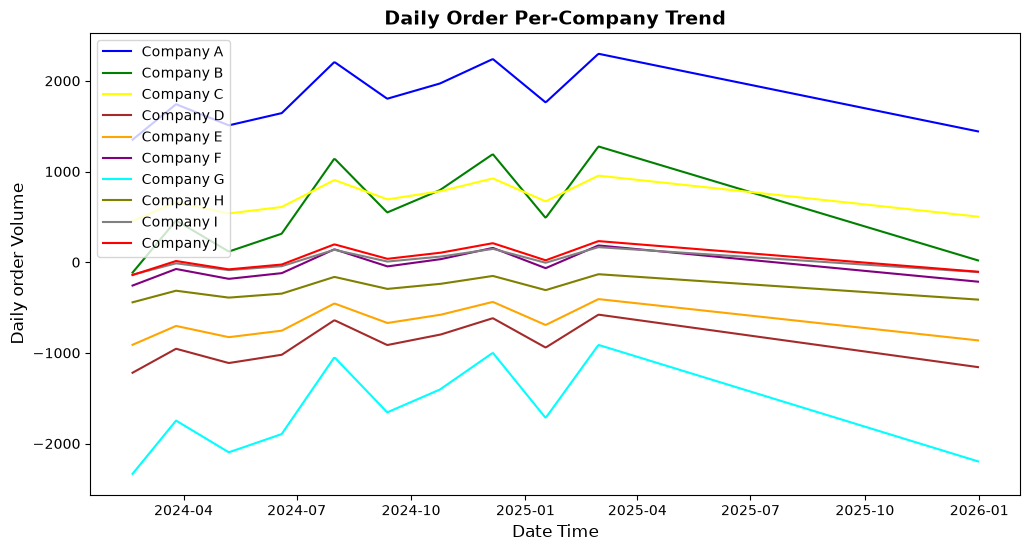

In [7]:
#plotting result 
fig, ax1 = plt.subplots(figsize=(12, 6))
# company A
company_a = forecast[forecast['ID']=='Company_A']
company_a_x = np.array(pd.to_datetime(company_a['ds']))
company_a_y = np.array(company_a['trend'])
# company B
company_b = forecast[forecast['ID']=='Company_B']
company_b_x = np.array(pd.to_datetime(company_b['ds']))
company_b_y = np.array(company_b['trend'])
# company C
company_c = forecast[forecast['ID']=='Company_C']
company_c_x = np.array(pd.to_datetime(company_c['ds']))
company_c_y = np.array(company_c['trend'])
# company D
company_d = forecast[forecast['ID']=='Company_D']
company_d_x = np.array(pd.to_datetime(company_d['ds']))
company_d_y = np.array(company_d['trend'])
# company E
company_e = forecast[forecast['ID']=='Company_E']
company_e_x = np.array(pd.to_datetime(company_e['ds']))
company_e_y = np.array(company_e['trend'])
# company F
company_f = forecast[forecast['ID']=='Company_F']
company_f_x = np.array(pd.to_datetime(company_f['ds']))
company_f_y = np.array(company_f['trend'])
# company G
company_g = forecast[forecast['ID']=='Company_G']
company_g_x = np.array(pd.to_datetime(company_g['ds']))
company_g_y = np.array(company_g['trend'])
# company H
company_h = forecast[forecast['ID']=='Company_H']
company_h_x = np.array(pd.to_datetime(company_h['ds']))
company_h_y = np.array(company_h['trend'])
# company I
company_i = forecast[forecast['ID']=='Company_I']
company_i_x = np.array(pd.to_datetime(company_i['ds']))
company_i_y = np.array(company_i['trend'])
# company J
company_j = forecast[forecast['ID']=='Company_J']
company_j_x = np.array(pd.to_datetime(company_j['ds']))
company_j_y = np.array(company_j['trend'])

plt.plot(company_a_x[50:], company_a_y[50:], color = 'blue', label = 'Company A')
plt.plot(company_b_x[50:], company_b_y[50:], color = 'green', label = 'Company B')
plt.plot(company_c_x[50:], company_c_y[50:], color = 'yellow', label = 'Company C')
plt.plot(company_d_x[50:], company_d_y[50:], color = 'brown', label = 'Company D')
plt.plot(company_e_x[50:], company_e_y[50:], color = 'orange', label = 'Company E')
plt.plot(company_f_x[50:], company_f_y[50:], color = 'purple', label = 'Company F')
plt.plot(company_g_x[50:], company_g_y[50:], color = 'cyan', label = 'Company G')
plt.plot(company_h_x[50:], company_h_y[50:], color = 'olive', label = 'Company H')
plt.plot(company_i_x[50:], company_i_y[50:], color = 'gray', label = 'Company I')
plt.plot(company_j_x[50:], company_j_y[50:], color = 'red', label = 'Company J')
plt.title('Daily Order Per-Company Trend', fontsize=14, fontweight='bold')

plt.xlabel('Date Time', fontsize = 12)
plt.ylabel('Daily order Volume',fontsize = 12 )
plt.legend()

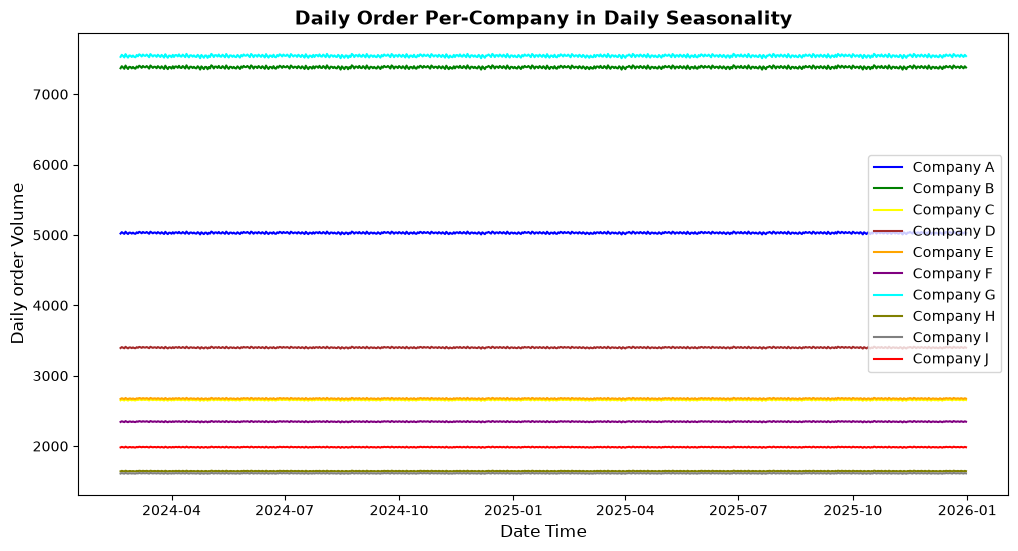

In [8]:
#plotting result 
fig, ax1 = plt.subplots(figsize=(12, 6))
# company A
company_a = forecast[forecast['ID']=='Company_A']
company_a_x = np.array(pd.to_datetime(company_a['ds']))
company_a_y = np.array(company_a['season_daily'])
# company B
company_b = forecast[forecast['ID']=='Company_B']
company_b_x = np.array(pd.to_datetime(company_b['ds']))
company_b_y = np.array(company_b['season_daily'])
# company C
company_c = forecast[forecast['ID']=='Company_C']
company_c_x = np.array(pd.to_datetime(company_c['ds']))
company_c_y = np.array(company_c['season_daily'])
# company D
company_d = forecast[forecast['ID']=='Company_D']
company_d_x = np.array(pd.to_datetime(company_d['ds']))
company_d_y = np.array(company_d['season_daily'])
# company E
company_e = forecast[forecast['ID']=='Company_E']
company_e_x = np.array(pd.to_datetime(company_e['ds']))
company_e_y = np.array(company_e['season_daily'])
# company F
company_f = forecast[forecast['ID']=='Company_F']
company_f_x = np.array(pd.to_datetime(company_f['ds']))
company_f_y = np.array(company_f['season_daily'])
# company G
company_g = forecast[forecast['ID']=='Company_G']
company_g_x = np.array(pd.to_datetime(company_g['ds']))
company_g_y = np.array(company_g['season_daily'])
# company H
company_h = forecast[forecast['ID']=='Company_H']
company_h_x = np.array(pd.to_datetime(company_h['ds']))
company_h_y = np.array(company_h['season_daily'])
# company I
company_i = forecast[forecast['ID']=='Company_I']
company_i_x = np.array(pd.to_datetime(company_i['ds']))
company_i_y = np.array(company_i['season_daily'])
# company J
company_j = forecast[forecast['ID']=='Company_J']
company_j_x = np.array(pd.to_datetime(company_j['ds']))
company_j_y = np.array(company_j['season_daily'])

plt.plot(company_a_x[50:], company_a_y[50:], color = 'blue', label = 'Company A')
plt.plot(company_b_x[50:], company_b_y[50:], color = 'green', label = 'Company B')
plt.plot(company_c_x[50:], company_c_y[50:], color = 'yellow', label = 'Company C')
plt.plot(company_d_x[50:], company_d_y[50:], color = 'brown', label = 'Company D')
plt.plot(company_e_x[50:], company_e_y[50:], color = 'orange', label = 'Company E')
plt.plot(company_f_x[50:], company_f_y[50:], color = 'purple', label = 'Company F')
plt.plot(company_g_x[50:], company_g_y[50:], color = 'cyan', label = 'Company G')
plt.plot(company_h_x[50:], company_h_y[50:], color = 'olive', label = 'Company H')
plt.plot(company_i_x[50:], company_i_y[50:], color = 'gray', label = 'Company I')
plt.plot(company_j_x[50:], company_j_y[50:], color = 'red', label = 'Company J')
plt.title('Daily Order Per-Company in Daily Seasonality', fontsize=14, fontweight='bold')

plt.xlabel('Date Time', fontsize = 12)
plt.ylabel('Daily order Volume',fontsize = 12 )
plt.legend()

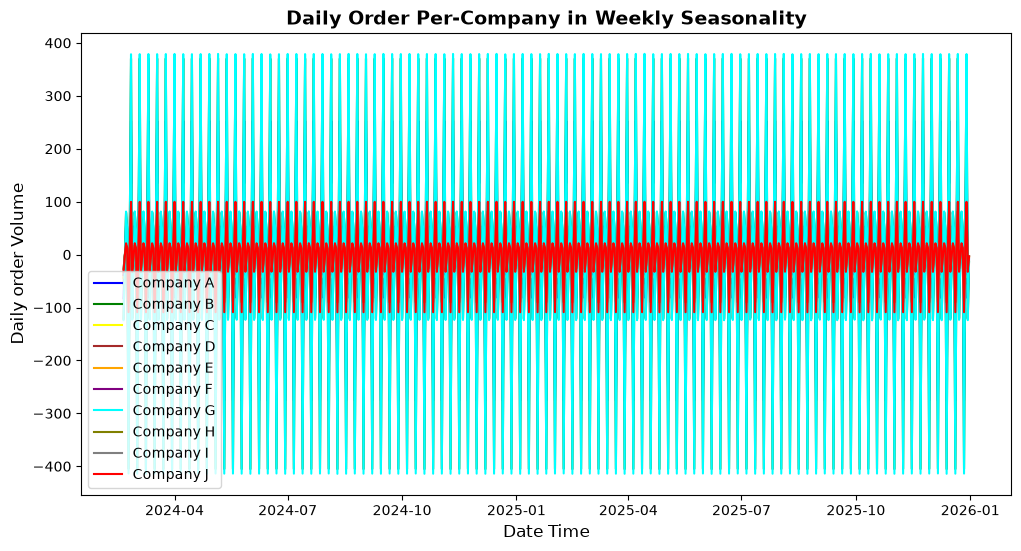

In [9]:
#plotting result 
fig, ax1 = plt.subplots(figsize=(12, 6))
# company A
company_a = forecast[forecast['ID']=='Company_A']
company_a_x = np.array(pd.to_datetime(company_a['ds']))
company_a_y = np.array(company_a['season_weekly'])
# company B
company_b = forecast[forecast['ID']=='Company_B']
company_b_x = np.array(pd.to_datetime(company_b['ds']))
company_b_y = np.array(company_b['season_weekly'])
# company C
company_c = forecast[forecast['ID']=='Company_C']
company_c_x = np.array(pd.to_datetime(company_c['ds']))
company_c_y = np.array(company_c['season_weekly'])
# company D
company_d = forecast[forecast['ID']=='Company_D']
company_d_x = np.array(pd.to_datetime(company_d['ds']))
company_d_y = np.array(company_d['season_weekly'])
# company E
company_e = forecast[forecast['ID']=='Company_E']
company_e_x = np.array(pd.to_datetime(company_e['ds']))
company_e_y = np.array(company_e['season_weekly'])
# company F
company_f = forecast[forecast['ID']=='Company_F']
company_f_x = np.array(pd.to_datetime(company_f['ds']))
company_f_y = np.array(company_f['season_weekly'])
# company G
company_g = forecast[forecast['ID']=='Company_G']
company_g_x = np.array(pd.to_datetime(company_g['ds']))
company_g_y = np.array(company_g['season_weekly'])
# company H
company_h = forecast[forecast['ID']=='Company_H']
company_h_x = np.array(pd.to_datetime(company_h['ds']))
company_h_y = np.array(company_h['season_weekly'])
# company I
company_i = forecast[forecast['ID']=='Company_I']
company_i_x = np.array(pd.to_datetime(company_i['ds']))
company_i_y = np.array(company_i['season_weekly'])
# company J
company_j = forecast[forecast['ID']=='Company_J']
company_j_x = np.array(pd.to_datetime(company_j['ds']))
company_j_y = np.array(company_j['season_weekly'])

plt.plot(company_a_x[50:], company_a_y[50:], color = 'blue', label = 'Company A')
plt.plot(company_b_x[50:], company_b_y[50:], color = 'green', label = 'Company B')
plt.plot(company_c_x[50:], company_c_y[50:], color = 'yellow', label = 'Company C')
plt.plot(company_d_x[50:], company_d_y[50:], color = 'brown', label = 'Company D')
plt.plot(company_e_x[50:], company_e_y[50:], color = 'orange', label = 'Company E')
plt.plot(company_f_x[50:], company_f_y[50:], color = 'purple', label = 'Company F')
plt.plot(company_g_x[50:], company_g_y[50:], color = 'cyan', label = 'Company G')
plt.plot(company_h_x[50:], company_h_y[50:], color = 'olive', label = 'Company H')
plt.plot(company_i_x[50:], company_i_y[50:], color = 'gray', label = 'Company I')
plt.plot(company_j_x[50:], company_j_y[50:], color = 'red', label = 'Company J')
plt.title('Daily Order Per-Company in Weekly Seasonality', fontsize=14, fontweight='bold')

plt.xlabel('Date Time', fontsize = 12)
plt.ylabel('Daily order Volume',fontsize = 12 )
plt.legend()

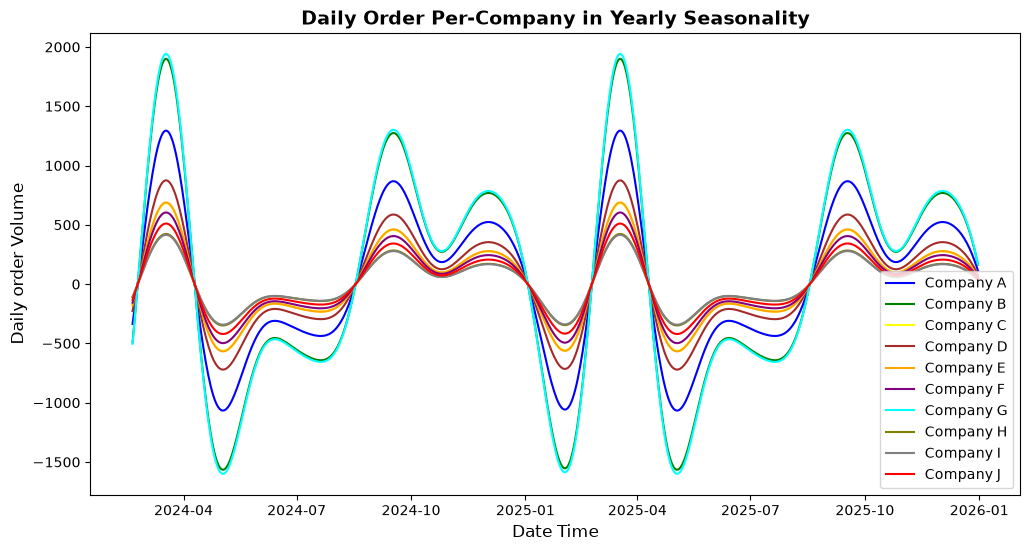

In [10]:
#plotting result 
fig, ax1 = plt.subplots(figsize=(12, 6))
# company A
company_a = forecast[forecast['ID']=='Company_A']
company_a_x = np.array(pd.to_datetime(company_a['ds']))
company_a_y = np.array(company_a['season_yearly'])
# company B
company_b = forecast[forecast['ID']=='Company_B']
company_b_x = np.array(pd.to_datetime(company_b['ds']))
company_b_y = np.array(company_b['season_yearly'])
# company C
company_c = forecast[forecast['ID']=='Company_C']
company_c_x = np.array(pd.to_datetime(company_c['ds']))
company_c_y = np.array(company_c['season_yearly'])
# company D
company_d = forecast[forecast['ID']=='Company_D']
company_d_x = np.array(pd.to_datetime(company_d['ds']))
company_d_y = np.array(company_d['season_yearly'])
# company E
company_e = forecast[forecast['ID']=='Company_E']
company_e_x = np.array(pd.to_datetime(company_e['ds']))
company_e_y = np.array(company_e['season_yearly'])
# company F
company_f = forecast[forecast['ID']=='Company_F']
company_f_x = np.array(pd.to_datetime(company_f['ds']))
company_f_y = np.array(company_f['season_yearly'])
# company G
company_g = forecast[forecast['ID']=='Company_G']
company_g_x = np.array(pd.to_datetime(company_g['ds']))
company_g_y = np.array(company_g['season_yearly'])
# company H
company_h = forecast[forecast['ID']=='Company_H']
company_h_x = np.array(pd.to_datetime(company_h['ds']))
company_h_y = np.array(company_h['season_yearly'])
# company I
company_i = forecast[forecast['ID']=='Company_I']
company_i_x = np.array(pd.to_datetime(company_i['ds']))
company_i_y = np.array(company_i['season_yearly'])
# company J
company_j = forecast[forecast['ID']=='Company_J']
company_j_x = np.array(pd.to_datetime(company_j['ds']))
company_j_y = np.array(company_j['season_yearly'])

plt.plot(company_a_x[50:], company_a_y[50:], color = 'blue', label = 'Company A')
plt.plot(company_b_x[50:], company_b_y[50:], color = 'green', label = 'Company B')
plt.plot(company_c_x[50:], company_c_y[50:], color = 'yellow', label = 'Company C')
plt.plot(company_d_x[50:], company_d_y[50:], color = 'brown', label = 'Company D')
plt.plot(company_e_x[50:], company_e_y[50:], color = 'orange', label = 'Company E')
plt.plot(company_f_x[50:], company_f_y[50:], color = 'purple', label = 'Company F')
plt.plot(company_g_x[50:], company_g_y[50:], color = 'cyan', label = 'Company G')
plt.plot(company_h_x[50:], company_h_y[50:], color = 'olive', label = 'Company H')
plt.plot(company_i_x[50:], company_i_y[50:], color = 'gray', label = 'Company I')
plt.plot(company_j_x[50:], company_j_y[50:], color = 'red', label = 'Company J')
plt.title('Daily Order Per-Company in Yearly Seasonality', fontsize=14, fontweight='bold')

plt.xlabel('Date Time', fontsize = 12)
plt.ylabel('Daily order Volume',fontsize = 12 )
plt.legend()